#### *Imports*

In [40]:
import torch
import torch.nn as nn
import torch.optim as optim
from helper_function import plot_results

torch.manual_seed(42)

#### *Data*

In [2]:
# Create two tensors of float32 data type for precise calculations
distances = torch.tensor([[1.0],[2.0],[3.0],[4.0]],dtype = torch.float32)
times = torch.tensor([[6.96],[12.11],[16.77],[22.21]],dtype = torch.float32)

#### *Model Building*

* Time = W * Distance + B -> *Linear Equation* 
* The goal is to find the best values for the weight (W) and bias (B) that fit the data
* Use nn.Sequential(nn.Linear(1, 1)) to create a linear model. 
    * nn.Linear(1, 1): The first 1 means it takes one input (distance), and the second 1 means one neuron that is   producing one output (predicted time).

In [4]:
# Create a model with one input (distance) and one output (time)
model = nn.Sequential(nn.Linear(in_features = 1, out_features = 1))

#### *Training*
* Two key tools which helps model learn from data
    * Loss Function: nn.MSELoss defines Mean Squared Error Loss function
        * It measures how wrong model predictions are. The model goal is to minimize this error
    * Optimizer: optim.SGD sets up the Stochastic Gradient Descent optimizer. It adjusts model's weight and bias parameters based on the error
        * lr=0.01: This learning rate controls how big each adjustment step is. Too Large might overshoot the values and too small takes training longer

In [5]:
# Define the loss function and the optimizer
loss_fn = nn.MSELoss()
optimizer = optim.SGD(params = model.parameters(),lr = 0.01)

Now it's time for model to learn. The training loop is where model cycles through the data repeatedly, gradually discovering the relationship between distance and delivery time.

model will train for 500 epochs (complete passes through data). During each epoch, these steps occur:

__optimizer.zero_grad()__: Clears gradients from the previous round. Without this, PyTorch would accumulate adjustments, which could break the learning process.

__outputs = model(distances)__: Performs the "forward pass", where the model makes predictions based on the input distances.

__loss = loss_function(outputs, times)__: Calculates how wrong the predicted outputs are by comparing them to the actual delivery times.

__loss.backward()__: The "backward pass" (backpropagation) is performed, which calculates exactly how to adjust the weight and bias to reduce the error.

__optimizer.step()__: Updates the model's parameters using those calculated adjustments.

The loss is printed every 50 epochs to allow to track the model's learning progress as the error decreases.

In [6]:
# Training loop
for epoch in range(500):
    # Reset the optimizer's gradients
    optimizer.zero_grad()

    # Forward pass: Compute the model's predictions
    output = model(distances)

    # Compute the loss
    loss = loss_fn(output,times)

    # Backward pass: Compute the gradients
    loss.backward()

    # Update the model's parameters
    optimizer.step()

    # Print loss every 50 epochs
    if (epoch+1) % 50 == 0:
        print(f"Epoch:{epoch + 1}, Loss: {loss.item()}")

Epoch:50, Loss: 0.08988543599843979
Epoch:100, Loss: 0.07318146526813507
Epoch:150, Loss: 0.06080767512321472
Epoch:200, Loss: 0.05163940414786339
Epoch:250, Loss: 0.044846080243587494
Epoch:300, Loss: 0.03981277346611023
Epoch:350, Loss: 0.03608356788754463
Epoch:400, Loss: 0.03332036733627319
Epoch:450, Loss: 0.03127291053533554
Epoch:500, Loss: 0.02975599467754364


#### Visualizing the Training Results

Let's see what your model learned. By plotting the model's predictions as a line against your actual delivery data points, you can check if it found a good pattern.

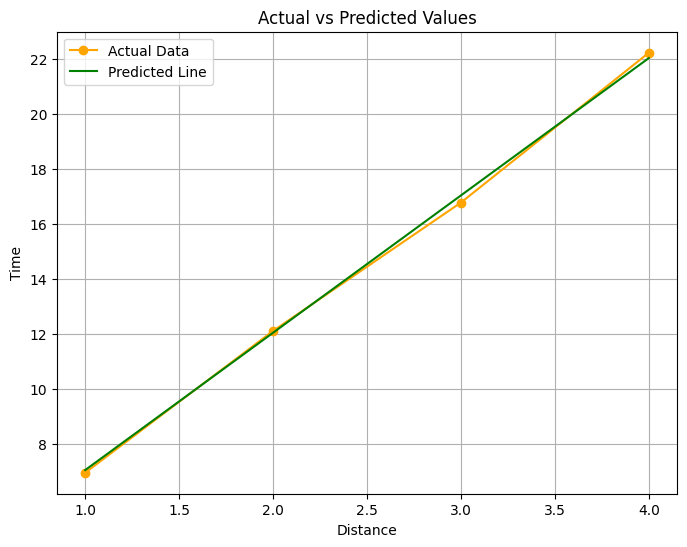

In [41]:
plot_results(model,distances,times)

#### *Make Inferences*

In [17]:
# Create a new variable to store the predicted time for a distance of 5.0
distance_to_predict = 6.0

The entire prediction process is wrapped in a with __torch.no_grad()__ block.
This tells PyTorch not train anymore, just making a prediction. This makes the process faster and more efficient.
A new input tensor is created using the __distance_to_predict__ variable.
This must be formatted as a 2D tensor ([[5.0]]), as the model expects this specific structure, not a simple number.
The trained model is called with this new tensor to generate a predicted_time.
After getting the prediction (which is also a tensor), the code extracts the actual numerical value from it using .item().

In [18]:
# Use torch.no_grad() context manager to disable gradient calculation for inference
with torch.no_grad():
    # Convert the python variable into a 2D pytorch tensor with float32 data type that the model expects as input
    new_distance = torch.tensor([[distance_to_predict]],dtype = torch.float32)
    # Pass the new data to the trained model to get the prediction
    predicted = model(new_distance)
    # Use .item() to extract the scalar value from the tensor for easier readability
    print(f"Prediction for a {distance_to_predict} unit distance: {predicted.item():.1f} minutes")

Prediction for a 6.0 unit distance: 32.0 minutes


#### *Inspecting the model learning*

In [ ]:
# Access the first layer and only layer in the sequential model
layer  = model[0]

# Get the weights and bias
weights,bias = layer.weight.item(),layer.bias.item()

print(f"Weights: {weights:.4f}")
print(f"Bias: {bias:.4f}")

Weights: 4.9863
Bias: 2.0707


#### *Testing Your Model on More Complex Data*

In [25]:
# Combined dataset: bikes for short distances, cars for longer ones
new_distances = torch.tensor([
    [1.0], [1.5], [2.0], [2.5], [3.0], [3.5], [4.0], [4.5], [5.0], [5.5],
    [6.0], [6.5], [7.0], [7.5], [8.0], [8.5], [9.0], [9.5], [10.0], [10.5],
    [11.0], [11.5], [12.0], [12.5], [13.0], [13.5], [14.0], [14.5], [15.0], [15.5],
    [16.0], [16.5], [17.0], [17.5], [18.0], [18.5], [19.0], [19.5], [20.0]
], dtype=torch.float32)

# Corresponding delivery times in minutes
new_times = torch.tensor([
    [6.96], [9.67], [12.11], [14.56], [16.77], [21.7], [26.52], [32.47], [37.15], [42.35],
    [46.1], [52.98], [57.76], [61.29], [66.15], [67.63], [69.45], [71.57], [72.8], [73.88],
    [76.34], [76.38], [78.34], [80.07], [81.86], [84.45], [83.98], [86.55], [88.33], [86.83],
    [89.24], [88.11], [88.16], [91.77], [92.27], [92.13], [90.73], [90.39], [92.98]
], dtype=torch.float32)

In [26]:
# Use trained model to generate predictions on new dataset
# Use torch.no_grad() context manager to disable gradient calculation for inference
with torch.no_grad():
    # Make prediction using the trained model
    predictions = model(new_distances)

In [33]:
predictions.data.numpy()

array([[  7.0570383],
       [  9.55021  ],
       [ 12.043382 ],
       [ 14.536553 ],
       [ 17.029724 ],
       [ 19.522896 ],
       [ 22.016068 ],
       [ 24.50924  ],
       [ 27.00241  ],
       [ 29.495583 ],
       [ 31.988754 ],
       [ 34.481926 ],
       [ 36.975098 ],
       [ 39.46827  ],
       [ 41.96144  ],
       [ 44.454613 ],
       [ 46.947784 ],
       [ 49.440956 ],
       [ 51.934128 ],
       [ 54.4273   ],
       [ 56.92047  ],
       [ 59.413643 ],
       [ 61.906815 ],
       [ 64.39999  ],
       [ 66.89316  ],
       [ 69.38633  ],
       [ 71.8795   ],
       [ 74.37267  ],
       [ 76.865845 ],
       [ 79.35902  ],
       [ 81.85219  ],
       [ 84.34536  ],
       [ 86.83853  ],
       [ 89.3317   ],
       [ 91.824875 ],
       [ 94.31805  ],
       [ 96.81122  ],
       [ 99.30439  ],
       [101.79756  ]], dtype=float32)

In [37]:
# Calculate the new loss
new_loss = loss_fn(predictions,new_times)
print(f"Loss on new dataset:{new_loss.item():.2f}")

Loss on new dataset:182.75


To understand why the loss is so high, let's visualize the plot. This plot reveals why the linear model struggles with the new data.

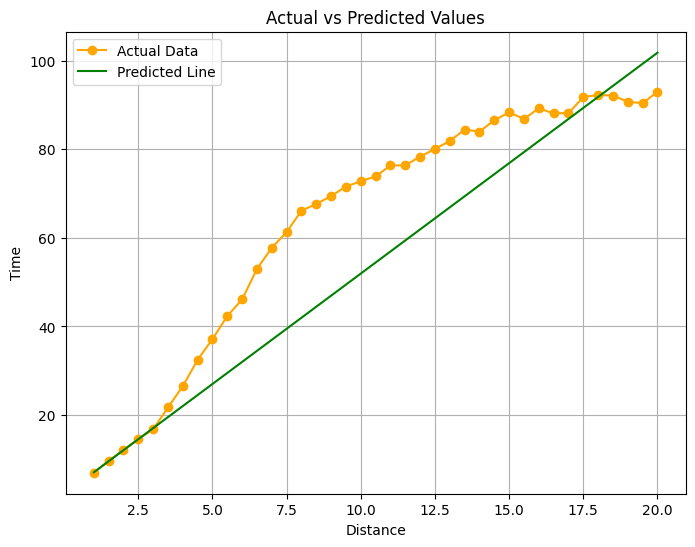

In [42]:
plot_results(model,new_distances,new_times)